In [29]:
import pandas as pd
import numpy as np
import random

# Java/pyspi
import jpype
from pyspi.calculator import Calculator
from pyspi.statistics.infotheory import *
from pyspi.data import Data

# File handling
from copy import deepcopy
from glob import glob
import os
import os.path as op

# Statistics
from scipy.stats import zscore

# Timing measures
import time

# Set seed to 127
random.seed(127)
np.random.seed(127)

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [41]:
%%R 

suppressPackageStartupMessages({
    library(cowplot)
    library(glue)
    library(patchwork)
    library(see)
    library(tidyverse)
})

# Set cowplot theme
theme_set(theme_cowplot())

### Point to pyspi installation of infodynamics and start up jpype

In [31]:
# Point to pyspi installation of infodynamics
jarLocation = "/Users/abry4213/github/pyspi/pyspi/lib/jidt/infodynamics.jar"

# Check if a JVM has already been started
# If not, start the JVM (add the "-Xmx" option with say 1024M if you get crashes due to not enough memory space)
if not jpype.isJVMStarted():
    jpype.startJVM(jpype.getDefaultJVMPath(), "-ea", "-Djava.class.path=" + jarLocation)

# Set seed to 127
random.seed(127)
np.random.seed(127)

## Load data

In [32]:

# Set seed to 127
random.seed(127)
np.random.seed(127)

# Load SPI groupings
infotheory_measure_info = pd.read_csv("data/infotheory_measure_info.csv")

# Read in brain regions
brain_region_lookup = pd.read_csv("data/Brain_Region_info.csv", index_col=False).reset_index(drop=True)

# Extract the 34 base cortical regions
base_regions = list(set(brain_region_lookup.Base_Region.tolist()))
source_base_region = "lateraloccipital"

# Load the subject time series data
subject_ID = "298051"
subject_data = pd.read_csv(f"data/HCP_{subject_ID}_rsfMRI_DesikanKilliany_TS.csv").values

# Extract the time series for the base region in the left hemisphere
source_index = brain_region_lookup.query("Base_Region == @source_base_region & Hemisphere == 'Left'").Region_Index.tolist()[0]
source_TS = subject_data[:, source_index]

# z-score the time series
source_TS = zscore(source_TS)

# Convert to Java array
source_TS_Array = jpype.JArray(jpype.JDouble)([float(x) for x in source_TS])

## Univariate measures: computed with JIDT directly using jpype

In [33]:
# Set seed to 127
random.seed(127)
np.random.seed(127)

# Create a Shannon entropy calculator with a Kozachenko--Leonenko ('kozachenko') density estimator
entropy_calcClass = jpype.JPackage("infodynamics.measures.continuous.kozachenko").EntropyCalculatorMultiVariateKozachenko
entropy_calc = entropy_calcClass()
entropy_calc.setProperty("NORMALISE", "true")
entropy_calc.setProperty("SEED", "127")
entropy_calc.initialise()

# Run again for Gaussian
entropy_calcClass_gauss = jpype.JPackage("infodynamics.measures.continuous.gaussian").EntropyCalculatorMultiVariateGaussian
entropy_calc_gauss = entropy_calcClass_gauss()
entropy_calc_gauss.setProperty("NORMALISE", "true")
entropy_calc_gauss.setProperty("SEED", "127")
entropy_calc_gauss.initialise()

# Create an Active Information Storage calculator with KSG ('kraskov') density estimator
AIScalcClass = jpype.JPackage("infodynamics.measures.continuous.kraskov").ActiveInfoStorageCalculatorKraskov
AIScalc = AIScalcClass()
AIScalc.setProperty("NORMALISE", "true")
AIScalc.setProperty("SEED", "127")
AIScalc.initialise()

# Run again for Gaussian
AIScalcClass_gauss = jpype.JPackage("infodynamics.measures.continuous.gaussian").ActiveInfoStorageCalculatorGaussian
AIScalc_gauss = AIScalcClass_gauss()
AIScalc_gauss.setProperty("NORMALISE", "true")
AIScalc_gauss.setProperty("SEED", "127")
AIScalc_gauss.initialise()

In [34]:
single_process_timing_list = []

# Compute entropy and AIS for each of the 34 base regions
for this_source_region in base_regions:
    # Get the region index for the left hemisphere
    this_region_index = brain_region_lookup.query("Base_Region == @this_source_region & Hemisphere == 'Left'").Region_Index.tolist()[0]
    
    # Extract the time series for this region
    this_region_TS = subject_data[:, this_region_index]
    
    # z-score the time series
    this_region_TS = zscore(this_region_TS)
    
    # Convert to Java array
    this_region_TS_Array = jpype.JArray(jpype.JDouble)([float(x) for x in this_region_TS])

    ######## Shannon Entropy Calculation ########
    
    # Add observations to entropy calculator
    source_entropy_calc = deepcopy(entropy_calc)
    source_entropy_calc.setObservations(this_region_TS_Array)

    # Start timer for entropy calculation
    start_time_entropy = time.perf_counter()

    # Compute the entropy
    entropy_value = source_entropy_calc.computeAverageLocalOfObservations()

    # End timer for entropy calculation
    end_time_entropy = time.perf_counter()
    entropy_time = end_time_entropy - start_time_entropy

    ######## Shannon Entropy Calculation, Gaussian ########
    # Add observations to entropy calculator
    source_entropy_calc_gauss = deepcopy(entropy_calc_gauss)
    source_entropy_calc_gauss.setObservations(this_region_TS_Array)

    # Start timer for entropy calculation
    start_time_entropy_gauss = time.perf_counter()

    # Compute the entropy
    entropy_value_gauss = source_entropy_calc_gauss.computeAverageLocalOfObservations()

    # End timer for entropy calculation
    end_time_entropy_gauss = time.perf_counter()
    entropy_time_gauss = end_time_entropy_gauss - start_time_entropy_gauss

    ######## Active Information Storage Calculation ########
    
    # Add observations to AIS calculator
    source_AIS_calc = deepcopy(AIScalc)
    source_AIS_calc.setObservations(this_region_TS_Array)

    # Start timer for AIS calculation
    start_time_AIS = time.perf_counter()

    # Compute the AIS
    AIS_value = source_AIS_calc.computeAverageLocalOfObservations()

    # End timer for AIS calculation
    end_time_AIS = time.perf_counter()
    AIS_time = end_time_AIS - start_time_AIS

    ######## Active Information Storage Calculation, Gaussian ########

    # Add observations to AIS calculator
    source_AIS_calc_gauss = deepcopy(AIScalc_gauss)
    source_AIS_calc_gauss.setObservations(this_region_TS_Array)

    # Start timer for AIS calculation
    start_time_AIS_gauss = time.perf_counter()

    # Compute the AIS
    AIS_value_gauss = source_AIS_calc_gauss.computeAverageLocalOfObservations()

    # End timer for AIS calculation
    end_time_AIS_gauss = time.perf_counter()
    AIS_time_gauss = end_time_AIS_gauss - start_time_AIS_gauss

    # Store timing results
    this_region_single_process_timing = pd.DataFrame({
        "Source_Region": [this_source_region, this_source_region, this_source_region, this_source_region],
        "Target_Region": [this_source_region, this_source_region, this_source_region, this_source_region],
        "Measure": ["Entropy", "Entropy", "AIS", "AIS"],
        "Estimator": ["Kozachenko", "Gaussian", "KSG", "Gaussian"],
        "Value": [entropy_value, entropy_value_gauss, AIS_value, AIS_value_gauss],
        "Computation_Time_Seconds": [entropy_time, entropy_time_gauss, AIS_time, AIS_time_gauss]
    })

    # Append to list
    single_process_timing_list.append(this_region_single_process_timing)

# Concatenate all timing results into a single DataFrame
single_process_timing_df = pd.concat(single_process_timing_list, ignore_index=True)
single_process_timing_df.head()

,Source_Region,Target_Region,Measure,Estimator,Value,Computation_Time_Seconds
0,posteriorcingulate,posteriorcingulate,Entropy,Kozachenko,1.440737,0.049153
1,posteriorcingulate,posteriorcingulate,Entropy,Gaussian,1.419355,0.000063
2,posteriorcingulate,posteriorcingulate,AIS,KSG,0.053877,0.026514
3,posteriorcingulate,posteriorcingulate,AIS,Gaussian,0.062976,0.000031
4,cuneus,cuneus,Entropy,Kozachenko,1.470793,0.036654


## Pairwise measures: Implemented using pyspi

### Define all nine estimators

In [36]:
JE_func = JointEntropy(estimator="kozachenko")
JE_func_gauss = JointEntropy(estimator="gaussian")
SI_func = StochasticInteraction(estimator="kozachenko")
SI_func_gauss = StochasticInteraction(estimator="gaussian")
MI_func = MutualInfo(estimator="kraskov", prop_k=4)
MI_func_gauss = MutualInfo(estimator="gaussian")
TLMI_func = TimeLaggedMutualInfo(estimator="kraskov", prop_k=4)
TLMI_func_gauss = TimeLaggedMutualInfo(estimator="gaussian")
DI_func = DirectedInfo(estimator="kozachenko")
DI_func_gauss = DirectedInfo(estimator="gaussian")
GC_func = TransferEntropy(estimator="gaussian", k_history=1, l_history=1)
TE_func = TransferEntropy(estimator="kraskov", prop_k=4, k_history=1, l_history=1)
CE_func = ConditionalEntropy(estimator="kozachenko")
CE_func_gauss = ConditionalEntropy(estimator="gaussian")
CCE_func = CausalEntropy(estimator="kozachenko")
CCE_func_gauss = CausalEntropy(estimator="gaussian")

measure_dict = {"Joint_Entropy": (JE_func, "Kozachenko", True, JE_func_gauss),
                "Stochastic_Interaction": (SI_func, "Kozachenko", True, SI_func_gauss),
                "Mutual_Info": (MI_func, "KSG", True, MI_func_gauss),
                "TLMI": (TLMI_func, "KSG", True, TLMI_func_gauss),
                "Directed_Info": (DI_func, "Kozachenko", True, DI_func_gauss),
                "Granger_Causality": (GC_func, "Gaussian", False),
                "Transfer_Entropy": (TE_func, "KSG", False),
                "Conditional_Entropy": (CE_func, "Kozachenko", True, CE_func_gauss),
                "Causal_Entropy": (CCE_func, "Kozachenko", True, CCE_func_gauss)}

In [38]:
all_time_pairwise_df_list = []

# Iterate over the base regions as the target regions
for target_base_region in base_regions:
    # Skip the source region
    if target_base_region == source_base_region:
        continue

    # Set the source
    random.seed(127)

    # Find the index for the target region, left hemisphere
    target_index = brain_region_lookup.query("Base_Region == @target_base_region & Hemisphere == 'Left'").Region_Index.tolist()[0]
        
    print("Target index: ", target_index)

    # Subset the subject_data numpy array to just target_index
    target_TS = subject_data[:, target_index]

    # z-score the time series
    target_TS = zscore(target_TS)

    # Reshape source_TS and target_TS to be 1 by 1200 numpy arrays
    source_TS = source_TS.reshape(1, -1)
    target_TS = target_TS.reshape(1, -1)

    # Combine left_TS and right_TS into a 2 by 1200 numpy array
    bilateral_arr_to_compute = np.concatenate((source_TS, target_TS), axis=0)

    # Convert to a Data object
    data_to_compute = Data(bilateral_arr_to_compute, normalise=False)

    # Loop over measures in measure_dict
    for measure_name, measure_tuple in measure_dict.items():
        measure_func = measure_tuple[0]
        estimator_name = measure_tuple[1]
        compute_gaussian = measure_tuple[2]

        if len(measure_tuple) == 4:
            measure_func_gauss = measure_tuple[3]

        # Compute main estimator first
        print(f"Computing {measure_name} ({estimator_name}) between {source_base_region} and {target_base_region}")

        # Reset the random seed before each computation for reproducibility
        random.seed(127)

        # Start timing
        start_time = time.perf_counter()

        # Compute the measure
        measure_value = measure_func.bivariate(data_to_compute)

        # End timing
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time

        print(f"{measure_name} ({estimator_name}) value: {measure_value:.4f}, computation time: {elapsed_time:.4f} seconds")

        # Store results in a DataFrame
        result_df = pd.DataFrame({
            "Source_Region": [source_base_region],
            "Target_Region": [target_base_region],
            "Measure": [measure_name],
            "Estimator": [estimator_name],
            "Value": [measure_value],
            "Computation_Time_Seconds": [elapsed_time]
        })

        all_time_pairwise_df_list.append(result_df)

        # Check if we need to compute Gaussian version
        if compute_gaussian:
            print(f"Computing {measure_name} (Gaussian) between {source_base_region} and {target_base_region}")

            # Reset the random seed before each computation for reproducibility
            random.seed(127)

            # Start timing
            start_time_gauss = time.perf_counter()

            # Compute the Gaussian measure
            measure_value_gauss = measure_func_gauss.bivariate(data_to_compute)

            # End timing
            end_time_gauss = time.perf_counter()
            elapsed_time_gauss = end_time_gauss - start_time_gauss

            print(f"{measure_name} (Gaussian) value: {measure_value_gauss:.4f}, computation time: {elapsed_time_gauss:.4f} seconds")

            # Store Gaussian results in a DataFrame
            result_df_gauss = pd.DataFrame({
                "Source_Region": [source_base_region],
                "Target_Region": [target_base_region],
                "Measure": [measure_name],
                "Estimator": ["Gaussian"],
                "Value": [measure_value_gauss],
                "Computation_Time_Seconds": [elapsed_time_gauss]
            })

            all_time_pairwise_df_list.append(result_df_gauss)

all_time_pairwise_df = pd.concat(all_time_pairwise_df_list, ignore_index=True)

# Combine with single process timing results
all_measure_timing_results = pd.concat([all_time_pairwise_df, single_process_timing_df], ignore_index=True)
all_measure_timing_results.head()

Target index:  21
[1/2] Skipping detrending of time series in the dataset...
[2/2] Skipping normalisation of time series in the dataset...

Computing Joint_Entropy (Kozachenko) between lateraloccipital and posteriorcingulate
Joint_Entropy (Kozachenko) value: 2.8136, computation time: 0.0950 seconds
Computing Joint_Entropy (Gaussian) between lateraloccipital and posteriorcingulate
Joint_Entropy (Gaussian) value: 2.8385, computation time: 0.0014 seconds
Computing Stochastic_Interaction (Kozachenko) between lateraloccipital and posteriorcingulate
Stochastic_Interaction (Kozachenko) value: 0.0469, computation time: 0.2360 seconds
Computing Stochastic_Interaction (Gaussian) between lateraloccipital and posteriorcingulate
Stochastic_Interaction (Gaussian) value: 0.0049, computation time: 0.0082 seconds
Computing Mutual_Info (KSG) between lateraloccipital and posteriorcingulate
Mutual_Info (KSG) value: -0.0011, computation time: 0.0060 seconds
Computing Mutual_Info (Gaussian) between lateralo

,Source_Region,Target_Region,Measure,Estimator,Value,Computation_Time_Seconds
0,lateraloccipital,posteriorcingulate,Joint_Entropy,Kozachenko,2.813631,0.095002
1,lateraloccipital,posteriorcingulate,Joint_Entropy,Gaussian,2.838472,0.001376
2,lateraloccipital,posteriorcingulate,Stochastic_Interaction,Kozachenko,0.046940,0.236025
3,lateraloccipital,posteriorcingulate,Stochastic_Interaction,Gaussian,0.004898,0.008232
4,lateraloccipital,posteriorcingulate,Mutual_Info,KSG,-0.001094,0.005977


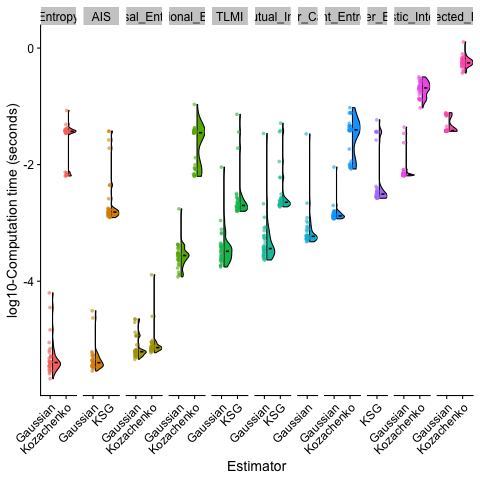

In [86]:
%%R -i all_measure_timing_results 

all_measure_timing_results %>% 
    mutate(Measure = fct_reorder(Measure, Computation_Time_Seconds, .fun='min')) %>%
    ggplot(data=., mapping=aes(x=Estimator, y=log10(Computation_Time_Seconds))) +
    geom_violinhalf(aes(fill=Measure), scale="width", color="black", position = position_nudge(x=0.15), width=1)  +
    geom_point(aes(color=Measure), position = position_jitter(width = 0.075, height=0),
                            size = 1.75, alpha=0.6, stroke=0) +
    stat_summary(color="black", fun="median", geom="crossbar", width=0.2, linewidth=0.3, 
            show.legend=FALSE, position = position_nudge(x=0.375)) +
    facet_grid(. ~ Measure, scales='free', space='free') +
    ylab("log10-Computation time (seconds)") +
    theme(legend.position='none',
          axis.text.x = element_text(angle=45, hjust=1))
# ggsave("figures/figure_drafting/infotheory_measure_computation_times_by_estimator.svg", width=9, height=5, units="in", dpi=300)

In [112]:
%%R -i all_measure_timing_results -o aggregated_times

aggregated_times <- all_measure_timing_results %>% 
    group_by(Measure, Estimator) %>%
    summarise(Median = median(Computation_Time_Seconds),
              IQR = IQR(Computation_Time_Seconds)) %>% 
    # Put Median and IQR in scientific notation with 1 decimal place
    mutate(Median = formatC(Median, format = "e", digits = 0),
           IQR = formatC(IQR, format = "e", digits = 0)) %>%
    mutate(Median__IQR = glue("{Median} +/- {IQR}")) %>%
    pivot_wider(names_from=Estimator, values_from=Median__IQR, id_cols=Measure)

`summarise()` has grouped output by 'Measure'. You can override using the
`.groups` argument.
